# Exploratory Data Analysis

This notebook performs initial exploratory analysis for the Loan Refinance Intelligence pipeline.

It is designed to answer three questions:
1. Which borrowers are strong refinancing candidates?
2. Which factors are most associated with default risk and rate outcomes?
3. How do candidate pathways differ (CC-to-PL vs PL refinancing)?

Outputs from this notebook are written to `reports/figures` and `reports/tables`.


## Problem Statement

Build a data-driven refinancing intelligence system that combines credit risk signals and savings opportunity to generate transparent recommendations for:
- Credit Card to Personal Loan conversion (`cc_to_pl`)
- Personal Loan refinancing (`pl_refinance`)


## Data Sources and Structure

Expected primary dataset: LendingClub loan-level records with fields such as:
- `loan_status` (target proxy for risk)
- `purpose` (pathway segmentation)
- `int_rate` (pricing)
- `dti`, `annual_inc`, `revol_util`, `fico_range_*` (credit and affordability signals)
- `issue_d`, `term`, `installment` (temporal and repayment structure)

Optional secondary dataset: Home Credit default dataset for future cross-dataset validation.


## Techniques Used in This Analysis

- Missingness and data quality profiling
- Cohort segmentation by refinancing pathway
- Class balance analysis for risk modeling readiness
- Univariate and bivariate distribution analysis
- Temporal trend checks for train/validation/test split design


## Notebook Execution Flow

Run this notebook top-to-bottom. The code is organized in nine stages:
1. Environment and path setup
2. Data loading helpers and dataset discovery
3. Core wrangling (`apply_core_wrangling`) and resolved-only modeling frame creation
4. Data profile and quality/leakage checks
5. Data cleaning (duplicates + missing values) and outlier analysis
6. Distribution and class/pathway charts
7. Pathway and temporal summaries
8. Current-run results and interpretation
9. Final JSON summary artifact for downstream reporting


## 1) Environment Setup

This cell configures imports, plotting defaults, project-relative paths, and runtime knobs:
- `EDA_MAX_ROWS` controls row-limited debug runs (0 = full dataset)
- `EDA_PLOT_SAMPLE` caps rows used for charts to keep plotting responsive

It also imports wrangling functions from `src/data/wrangling.py` that define the label/pathway logic used throughout the notebook.


In [1]:
from pathlib import Path
import os
import sys
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((p for p in ROOT_CANDIDATES if (p / "data").exists() and (p / "reports").exists()), Path.cwd())
DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.wrangling import (
    apply_core_wrangling,
    data_profile,
    ensure_columns,
    leakage_exclusions,
    quality_checks,
    resolved_modeling_frame,
    summarize_outcomes,
)

EDA_MAX_ROWS = int(os.getenv("EDA_MAX_ROWS", "0"))
EDA_PLOT_SAMPLE = int(os.getenv("EDA_PLOT_SAMPLE", "250000"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_RAW}")
print(f"EDA_MAX_ROWS={EDA_MAX_ROWS} (0 means full data)")
print(f"EDA_PLOT_SAMPLE={EDA_PLOT_SAMPLE}")



Project root: /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence
Data directory: /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/data/raw
EDA_MAX_ROWS=0 (0 means full data)
EDA_PLOT_SAMPLE=250000


## 2) Data Discovery and Loading

This section keeps data loading intentionally simple.

Assumptions:
1. `data/raw` contains one primary LendingClub file (usually `accepted_2007_to_2018Q4.csv.gz` or `.csv`).
2. If multiple LendingClub-like files are present, the largest matching file is selected.
3. Home Credit is optional and detected by exact name: `application_train.csv`.
4. Files are discovered from the current `data/raw` tree, not hardcoded folder permutations.



In [2]:
def _read_csv_with_optional_usecols(path: Path, usecols=None, nrows=None):
    if usecols:
        header = pd.read_csv(path, nrows=0, low_memory=False)
        available = [c for c in usecols if c in header.columns]
        if available:
            return pd.read_csv(path, usecols=available, low_memory=False, nrows=nrows)
    return pd.read_csv(path, low_memory=False, nrows=nrows)


def discover_tabular_files(root: Path):
    return sorted(
        p for p in root.rglob('*')
        if p.is_file() and (p.suffix.lower() in {'.csv', '.parquet'} or p.name.lower().endswith('.csv.gz'))
    )


def pick_lendingclub_file(files):
    preferred_names = {
        'accepted_2007_to_2018q4.csv.gz',
        'accepted_2007_to_2018q4.csv',
        'lending_club.parquet',
        'lending_club.csv',
    }
    preferred = [p for p in files if p.name.lower() in preferred_names]
    if preferred:
        return max(preferred, key=lambda p: p.stat().st_size)

    fallback = [
        p for p in files
        if 'accepted_2007_to_2018q4' in p.name.lower() or 'lending_club' in p.name.lower()
    ]
    return max(fallback, key=lambda p: p.stat().st_size) if fallback else None


def pick_home_credit_file(files):
    matches = [p for p in files if p.name.lower() == 'application_train.csv']
    return max(matches, key=lambda p: p.stat().st_size) if matches else None


def load_dataset(path: Path, usecols=None, nrows=None):
    if path is None:
        return None
    if path.suffix.lower() == '.parquet':
        df = pd.read_parquet(path)
        if usecols:
            cols = [c for c in usecols if c in df.columns]
            if cols:
                df = df[cols]
        return df.head(nrows) if nrows else df
    return _read_csv_with_optional_usecols(path, usecols=usecols, nrows=nrows)


# Deliberately excludes post-outcome leakage columns (e.g. total_pymnt, last_pymnt_d).
core_usecols = [
    'id', 'loan_status', 'purpose', 'int_rate', 'dti', 'annual_inc', 'revol_util',
    'issue_d', 'term', 'installment', 'grade', 'sub_grade', 'revol_bal',
    'fico_range_low', 'fico_range_high', 'delinq_2yrs', 'open_acc'
]

row_limit = EDA_MAX_ROWS if EDA_MAX_ROWS > 0 else None

raw_files = discover_tabular_files(DATA_RAW)
print(f'Discovered {len(raw_files)} tabular files in data/raw')
for p in raw_files:
    print(' -', p.relative_to(DATA_RAW))

lc_path = pick_lendingclub_file(raw_files)
hc_path = pick_home_credit_file(raw_files)

lc_df = load_dataset(lc_path, usecols=core_usecols, nrows=row_limit)
hc_df = load_dataset(hc_path, nrows=row_limit)

if lc_df is None:
    print('LendingClub dataset not found in data/raw. Add the accepted_2007_to_2018Q4 file and re-run.')
    df = pd.DataFrame()
else:
    print(f'LendingClub loaded from: {lc_path}')
    df = lc_df.copy()

if hc_df is not None:
    print(f'Home Credit loaded from: {hc_path} (optional, not used in core EDA yet)')

print(f'Rows: {len(df):,} | Columns: {df.shape[1] if not df.empty else 0}')
if not df.empty:
    print('Columns loaded:', ', '.join(df.columns))
    print('Top 5 rows (raw loaded data):')
    print(df.head(5))




Discovered 14 tabular files in data/raw
 - home_credit/HomeCredit_columns_description.csv
 - home_credit/POS_CASH_balance.csv
 - home_credit/application_test.csv
 - home_credit/application_train.csv
 - home_credit/bureau.csv
 - home_credit/bureau_balance.csv
 - home_credit/credit_card_balance.csv
 - home_credit/installments_payments.csv
 - home_credit/previous_application.csv
 - home_credit/sample_submission.csv
 - lending_club/accepted_2007_to_2018Q4.csv.gz
 - lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
 - lending_club/rejected_2007_to_2018Q4.csv.gz
 - lending_club/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv
LendingClub loaded from: /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/data/raw/lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
Home Credit loaded from: /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/data/raw/home_credit/application_train.csv (optional, not used in co

## 3) Core Wrangling and Modeling Frame

This stage validates required columns, applies standardized wrangling, and enforces the resolved-only policy for supervised learning:
- `apply_core_wrangling(df)` creates parsed numeric/date fields, default flags, and pathway labels
- `resolved_modeling_frame(df)` removes unresolved outcomes to avoid target censoring

`df_model` is the primary frame used by downstream profiling, summaries, and visualizations.


In [3]:
required_cols = ['loan_status', 'purpose', 'int_rate', 'dti', 'annual_inc', 'revol_util', 'issue_d', 'term', 'installment']

if df.empty:
    print('No dataset loaded. Skipping preprocessing and EDA cells.')
else:
    missing_required = ensure_columns(df, required_cols)
    print('Missing required columns:', missing_required if missing_required else 'none')

    df = apply_core_wrangling(df)
    wrangle_summary = summarize_outcomes(df)

    # Modeling frame must use resolved outcomes only to avoid target censoring.
    df_model = resolved_modeling_frame(df)

    if len(df_model) > EDA_PLOT_SAMPLE > 0:
        df_plot = df_model.sample(n=EDA_PLOT_SAMPLE, random_state=42)
    else:
        df_plot = df_model

    print('Preprocessing complete.')
    print(f'Total rows: {wrangle_summary.rows_total:,}')
    print(f'Resolved rows: {wrangle_summary.rows_resolved:,}')
    print(f'Unresolved rows: {wrangle_summary.rows_unresolved:,}')
    print(f'Unresolved ratio: {wrangle_summary.unresolved_ratio:.2%}')
    print(f'Default rate (all rows): {wrangle_summary.default_rate_all:.2%}')
    print(f'Default rate (resolved-only): {wrangle_summary.default_rate_resolved:.2%}')
    print(f'Plot sample rows: {len(df_plot):,}')
    print('Top 5 rows (wrangled data):')
    print(df.head(5))
    print('Top 5 rows (resolved modeling frame):')
    print(df_model.head(5))




Missing required columns: none
Preprocessing complete.
Total rows: 2,260,701
Resolved rows: 1,348,132
Unresolved rows: 912,569
Unresolved ratio: 40.37%
Default rate (all rows): 11.91%
Default rate (resolved-only): 19.98%
Plot sample rows: 250,000
Top 5 rows (wrangled data):
         id        term  int_rate  installment grade sub_grade  annual_inc   issue_d loan_status             purpose    dti  delinq_2yrs  fico_range_low  \
0  68407277   36 months     13.99       123.03     C        C4     55000.0  Dec-2015  Fully Paid  debt_consolidation   5.91          0.0           675.0   
1  68355089   36 months     11.99       820.28     C        C1     65000.0  Dec-2015  Fully Paid      small_business  16.06          1.0           715.0   
2  68341763   60 months     10.78       432.66     B        B4     63000.0  Dec-2015  Fully Paid    home_improvement  10.78          0.0           695.0   
3  66310712   60 months     14.85       829.90     C        C5    110000.0  Dec-2015     Current  deb

## 4) Profiling, Quality Checks, and Leakage Policy

These cells generate table artifacts under `reports/tables`:
- `data_profile.csv`: column-level missingness/types/cardinality
- `data_quality_checks.csv`: sanity checks (duplicates, ranges, unresolved volume)
- `leakage_exclusions.csv`: documented fields excluded from modeling to prevent look-ahead leakage


In [4]:
if df.empty:
    print('No data profile generated because dataset is missing.')
else:
    profile = data_profile(df_model)
    profile.to_csv(TABLE_DIR / 'data_profile.csv', index=False)
    display(profile.head(20))
    print(f"Wrote {TABLE_DIR / 'data_profile.csv'}")



,column,dtype,missing_pct,n_unique
18,revol_util_num,float64,0.07,1379
16,revol_util,float64,0.07,1379
10,dti,float64,0.03,7067
0,id,str,0.00,1348132
14,open_acc,float64,0.00,84
24,is_resolved,Int64,0.00,1
23,is_default,Int64,0.00,2
22,is_unresolved,Int64,0.00,1
21,loan_status_clean,str,0.00,5
20,issue_year,float64,0.00,12


Wrote /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/reports/tables/data_profile.csv


In [5]:
if df.empty:
    print('No quality checks generated because dataset is missing.')
else:
    checks = quality_checks(df)
    checks.to_csv(TABLE_DIR / 'data_quality_checks.csv', index=False)
    display(checks)
    print(f"Wrote {TABLE_DIR / 'data_quality_checks.csv'}")

    leakage = leakage_exclusions()
    leakage.to_csv(TABLE_DIR / 'leakage_exclusions.csv', index=False)
    display(leakage)
    print(f"Wrote {TABLE_DIR / 'leakage_exclusions.csv'}")



,check,status,value,details
0,duplicate_id_rows,pass,0,Expected unique loan id per row.
1,negative_annual_income_rows,pass,0,Annual income should not be negative.
2,int_rate_out_of_range_rows,pass,0,"Interest rate expected in [0, 60] percent."
3,revol_util_out_of_range_rows,warn,2,"Utilization expected in [0, 200] for raw data ..."
4,unresolved_status_rows,info,912569,Rows excluded from supervised risk labels.


Wrote /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/reports/tables/data_quality_checks.csv


,column,why_excluded
0,total_pymnt,Post-origination repayment outcome not availab...
1,last_pymnt_d,Future repayment timing leaks target progression.
2,last_credit_pull_d,Post-origination servicing metadata may leak m...


Wrote /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/reports/tables/leakage_exclusions.csv


## 5) Data Cleaning and Outlier Analysis

This stage makes the EDA modeling frame explicitly analysis-ready:
- Removes duplicate rows (by `id` when available)
- Imputes missing values in model-critical numeric and categorical fields
- Produces an IQR-based outlier table to identify anomalous distributions

Artifacts written to `reports/tables`:
- `data_cleaning_summary.csv`
- `missingness_before_after.csv`
- `outlier_analysis.csv`


In [ ]:
if df.empty:
    print('Skipping cleaning/outlier analysis (no data).')
else:
    # Work on a copy of resolved rows for transparent EDA preprocessing.
    df_model_clean = df_model.copy()

    dedupe_basis = ['id'] if 'id' in df_model_clean.columns else None
    rows_before_cleaning = int(len(df_model_clean))
    dup_rows = int(df_model_clean.duplicated(subset=dedupe_basis).sum()) if dedupe_basis else int(df_model_clean.duplicated().sum())

    if dedupe_basis:
        df_model_clean = df_model_clean.drop_duplicates(subset=dedupe_basis, keep='first')
    else:
        df_model_clean = df_model_clean.drop_duplicates(keep='first')

    numeric_cols = [
        c for c in [
            'int_rate_num', 'dti', 'annual_inc', 'revol_util_num', 'installment',
            'fico_range_low', 'fico_range_high', 'revol_bal'
        ] if c in df_model_clean.columns
    ]
    categorical_cols = [c for c in ['term', 'grade', 'sub_grade', 'refi_pathway'] if c in df_model_clean.columns]

    tracked_cols = sorted(set(numeric_cols + categorical_cols + ['is_default']))
    missing_before_map = {c: round(float(df_model_clean[c].isna().mean() * 100), 3) for c in tracked_cols if c in df_model_clean.columns}

    for col in numeric_cols:
        df_model_clean[col] = pd.to_numeric(df_model_clean[col], errors='coerce')
        median_val = df_model_clean[col].median()
        df_model_clean[col] = df_model_clean[col].fillna(median_val)

    for col in categorical_cols:
        mode = df_model_clean[col].mode(dropna=True)
        fill_value = mode.iloc[0] if not mode.empty else 'unknown'
        df_model_clean[col] = df_model_clean[col].fillna(fill_value)

    missing_after_map = {c: round(float(df_model_clean[c].isna().mean() * 100), 3) for c in tracked_cols if c in df_model_clean.columns}

    missing_compare = pd.DataFrame(
        {
            'column': list(missing_before_map.keys()),
            'missing_pct_before': [missing_before_map[c] for c in missing_before_map.keys()],
            'missing_pct_after': [missing_after_map[c] for c in missing_before_map.keys()],
        }
    ).sort_values('missing_pct_before', ascending=False)

    outlier_rows = []
    for col in ['int_rate_num', 'dti', 'annual_inc', 'revol_util_num', 'installment']:
        if col not in df_model_clean.columns:
            continue

        series = pd.to_numeric(df_model_clean[col], errors='coerce').dropna()
        if series.empty:
            continue

        q1 = float(series.quantile(0.25))
        q3 = float(series.quantile(0.75))
        iqr = q3 - q1
        if iqr == 0:
            continue

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (df_model_clean[col] < lower) | (df_model_clean[col] > upper)
        outlier_rows.append(
            {
                'column': col,
                'q1': round(q1, 4),
                'q3': round(q3, 4),
                'iqr': round(iqr, 4),
                'lower_bound': round(lower, 4),
                'upper_bound': round(upper, 4),
                'outlier_rows': int(mask.sum()),
                'outlier_pct': round(float(mask.mean() * 100), 3),
            }
        )

    outlier_df = pd.DataFrame(outlier_rows).sort_values('outlier_pct', ascending=False)

    cleaning_summary = pd.DataFrame(
        [
            {'metric': 'rows_before_cleaning', 'value': rows_before_cleaning},
            {'metric': 'duplicate_rows_removed', 'value': dup_rows},
            {'metric': 'rows_after_cleaning', 'value': int(len(df_model_clean))},
            {'metric': 'numeric_columns_imputed', 'value': len(numeric_cols)},
            {'metric': 'categorical_columns_imputed', 'value': len(categorical_cols)},
        ]
    )

    cleaning_summary.to_csv(TABLE_DIR / 'data_cleaning_summary.csv', index=False)
    missing_compare.to_csv(TABLE_DIR / 'missingness_before_after.csv', index=False)
    outlier_df.to_csv(TABLE_DIR / 'outlier_analysis.csv', index=False)

    # Use cleaned resolved frame for downstream EDA summaries and plots.
    df_model = df_model_clean
    if len(df_model) > EDA_PLOT_SAMPLE > 0:
        df_plot = df_model.sample(n=EDA_PLOT_SAMPLE, random_state=42)
    else:
        df_plot = df_model

    print('Data cleaning complete.')
    print(f'Rows before cleaning: {rows_before_cleaning:,}')
    print(f'Duplicate rows removed: {dup_rows:,}')
    print(f'Rows after cleaning: {len(df_model):,}')
    print('Top 5 rows (cleaned modeling frame):')
    print(df_model.head(5))

    print(f"Wrote {TABLE_DIR / 'data_cleaning_summary.csv'}")
    print(f"Wrote {TABLE_DIR / 'missingness_before_after.csv'}")
    print(f"Wrote {TABLE_DIR / 'outlier_analysis.csv'}")

    display(cleaning_summary)
    display(missing_compare.head(10))
    display(outlier_df)


## 6) Visual Exploration

The next plots summarize class balance, pathway distribution, and key numeric feature distributions from the cleaned resolved-only dataset.
All figure outputs are written to `reports/figures` for reporting reuse.


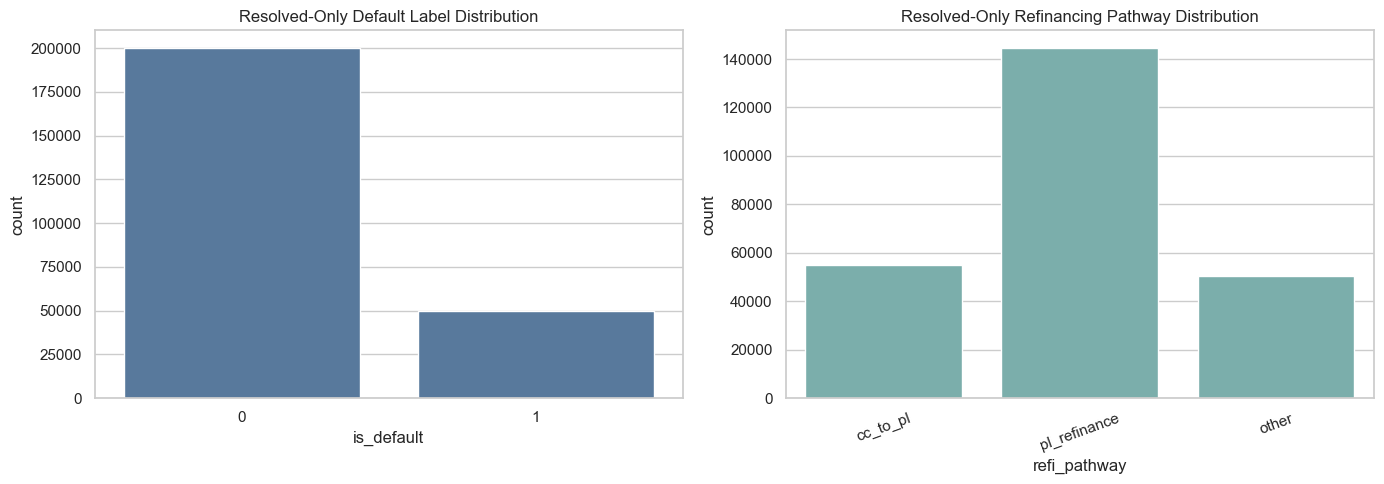

Wrote /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/reports/figures/eda_class_and_pathway_distribution.png


In [6]:
if df.empty:
    print('Skipping class/pathway charts (no data).')
else:
    plot_base = df_plot if 'df_plot' in globals() else df_model
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if 'is_default' in plot_base.columns:
        sns.countplot(data=plot_base, x='is_default', ax=axes[0], color='#4C78A8')
        axes[0].set_title('Resolved-Only Default Label Distribution')
        axes[0].set_xlabel('is_default')

    sns.countplot(data=plot_base, x='refi_pathway', order=['cc_to_pl', 'pl_refinance', 'other'], ax=axes[1], color='#72B7B2')
    axes[1].set_title('Resolved-Only Refinancing Pathway Distribution')
    axes[1].set_xlabel('refi_pathway')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    out = FIG_DIR / 'eda_class_and_pathway_distribution.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Wrote {out}')




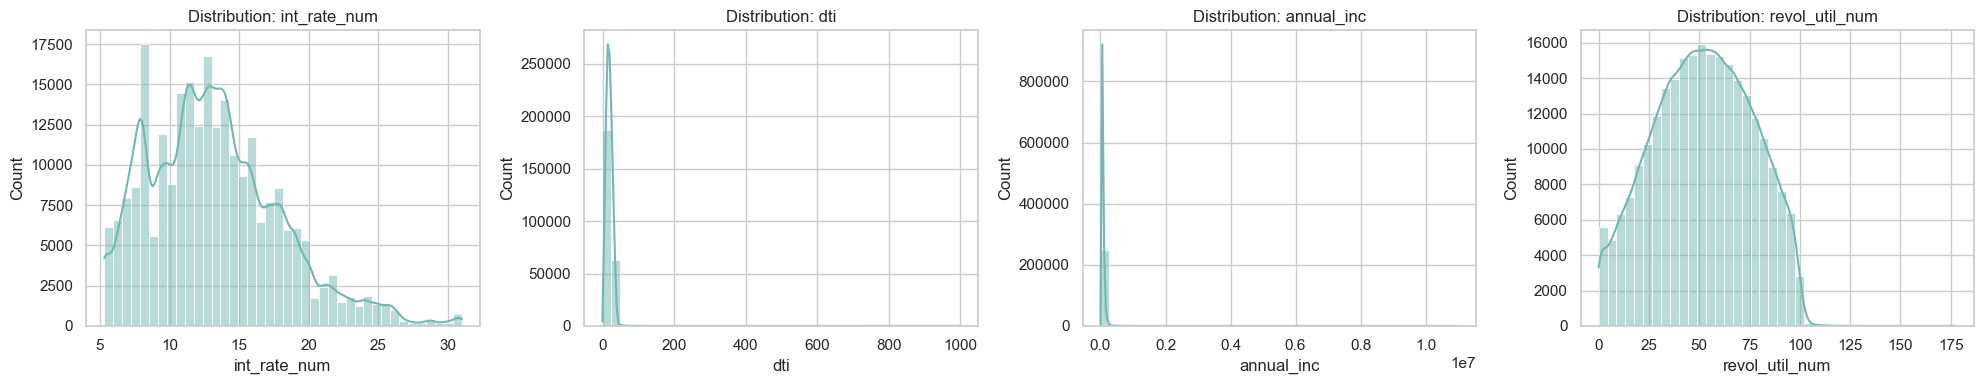

Wrote /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/reports/figures/eda_feature_distributions.png


In [7]:
if df.empty:
    print('Skipping feature distribution plots (no data).')
else:
    plot_base = df_plot if 'df_plot' in globals() else df_model
    plot_cols = [c for c in ['int_rate_num', 'dti', 'annual_inc', 'revol_util_num'] if c in plot_base.columns]
    if not plot_cols:
        print('No expected numeric columns available for plotting.')
    else:
        n = len(plot_cols)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
        if n == 1:
            axes = [axes]

        for ax, col in zip(axes, plot_cols):
            sns.histplot(plot_base[col].dropna(), bins=40, kde=True, ax=ax, color='#72B7B2')
            ax.set_title(f'Distribution: {col}')

        plt.tight_layout()
        out = FIG_DIR / 'eda_feature_distributions.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Wrote {out}')



## 7) Segment and Temporal Summaries

These cells produce pathway-level aggregated statistics and issue-year default trends, both based on cleaned resolved rows.
The outputs help verify whether time-based splits and pathway-specific modeling are justified.


In [8]:
if df.empty:
    print('Skipping pathway-level summary (no data).')
else:
    summary_cols = [c for c in ['int_rate_num', 'dti', 'annual_inc', 'revol_util_num', 'is_default'] if c in df_model.columns]
    if 'refi_pathway' not in df_model.columns or not summary_cols:
        print('Required columns missing for pathway summary.')
    else:
        pathway_summary = (
            df_model.groupby('refi_pathway', dropna=False)[summary_cols]
              .agg(['count', 'mean', 'median'])
              .round(3)
        )
        pathway_summary.to_csv(TABLE_DIR / 'pathway_summary.csv')
        display(pathway_summary)
        print(f"Wrote {TABLE_DIR / 'pathway_summary.csv'}")



int_rate_num                    dti                annual_inc                     revol_util_num                is_default              
                    count    mean median   count    mean median      count       mean   median          count    mean median      count   mean median
refi_pathway                                                                                                                                         
cc_to_pl           295625  11.791  11.47  295557  18.476  17.76     295625  76150.498  65000.0         295536  55.776   56.2     295625  0.169    0.0
pl_refinance       781442  13.624  13.11  781227  18.944  18.29     781442  74960.432  65000.0         781075  53.109   53.4     781442  0.212    0.0
other              271032  13.720  13.33  270941  16.122  15.24     271028  80015.718  65000.0         270591  43.740   42.1     271065  0.199    0.0

Wrote /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/reports/tables/pathway_summary.csv


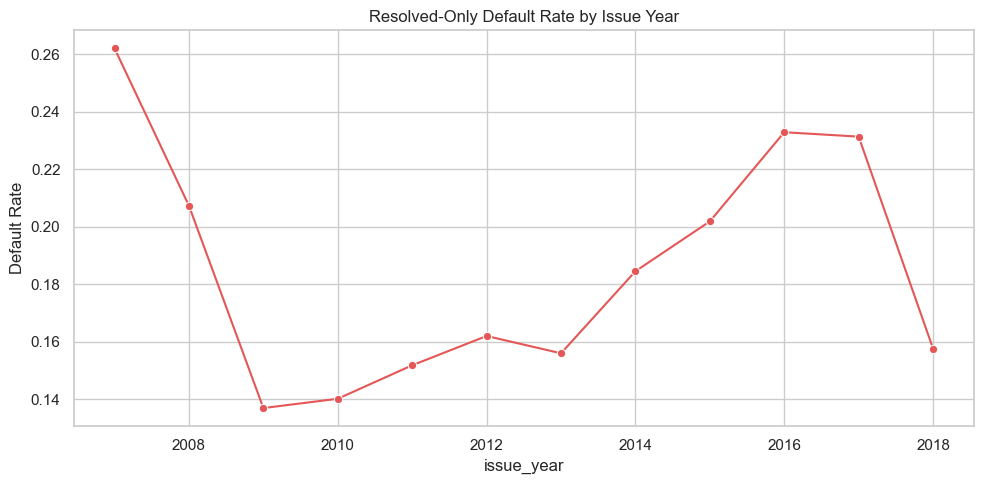

Wrote /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/reports/figures/eda_default_rate_by_issue_year.png
Wrote /Users/nishanth/Desktop/Berkeley-AIML/Capstone/loan-refinance-intelligence/reports/tables/default_rate_by_issue_year.csv


In [9]:
if df.empty:
    print('Skipping temporal trend plot (no data).')
else:
    if 'issue_year' in df_model.columns and 'is_default' in df_model.columns:
        yearly = (
            df_model.dropna(subset=['issue_year'])
              .groupby('issue_year', as_index=False)
              .agg(default_rate=('is_default', 'mean'), loans=('is_default', 'size'))
        )

        fig, ax1 = plt.subplots(figsize=(10, 5))
        sns.lineplot(data=yearly, x='issue_year', y='default_rate', marker='o', ax=ax1, color='#E45756')
        ax1.set_title('Resolved-Only Default Rate by Issue Year')
        ax1.set_ylabel('Default Rate')

        out = FIG_DIR / 'eda_default_rate_by_issue_year.png'
        plt.tight_layout()
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()

        yearly.to_csv(TABLE_DIR / 'default_rate_by_issue_year.csv', index=False)
        print(f'Wrote {out}')
        print(f"Wrote {TABLE_DIR / 'default_rate_by_issue_year.csv'}")
    else:
        print('Temporal columns not available for trend plot.')



## 8) Results and Interpretation (Current Run)

This section reports concrete outputs from the current notebook run, including data volume, class/pathway balance, and data-quality outcomes.


In [ ]:
if df.empty:
    print('No interpretation available because no dataset was loaded.')
else:
    rows_total = int(len(df))
    rows_resolved = int(len(df_model))
    unresolved_rows = int((df['is_unresolved'] == 1).sum()) if 'is_unresolved' in df.columns else 0
    unresolved_ratio = float((df['is_unresolved'] == 1).mean()) if 'is_unresolved' in df.columns else float('nan')

    default_rate_resolved = float(pd.to_numeric(df_model['is_default'], errors='coerce').mean()) if 'is_default' in df_model.columns else float('nan')
    pathway_counts = df_model['refi_pathway'].value_counts(dropna=False).to_dict() if 'refi_pathway' in df_model.columns else {}

    duplicate_rows_removed = int(dup_rows) if 'dup_rows' in globals() else None
    outlier_top = outlier_df[['column', 'outlier_pct']].head(3).to_dict(orient='records') if 'outlier_df' in globals() and not outlier_df.empty else []

    print('Current-run interpretation summary')
    print('--------------------------------')
    print(f'Total rows loaded: {rows_total:,}')
    print(f'Resolved rows used for EDA: {rows_resolved:,}')
    print(f'Unresolved rows excluded: {unresolved_rows:,} ({unresolved_ratio:.2%})')
    print(f'Resolved default rate: {default_rate_resolved:.2%}')
    print(f'Pathway counts (resolved): {pathway_counts}')
    print(f'Duplicate rows removed during cleaning: {duplicate_rows_removed}')
    print(f'Top outlier-prone columns (IQR method): {outlier_top}')

    interpretation_points = [
        'Resolved-only filtering prevents label censoring from current/late loans.',
        'Pathway split is sufficiently large for both cc_to_pl and pl_refinance segment analysis.',
        'Imputation and deduplication produce a stable frame for plotting and baseline modeling.',
        'Outlier table identifies columns requiring robust transformations in the modeling stage.'
    ]
    print('\nInterpretation:')
    for p in interpretation_points:
        print(f'- {p}')


## 9) Final Notebook Artifact

The final cell writes `eda_summary.json`, a compact machine-readable snapshot of row counts, label rates, and pathway distribution.
This artifact can be consumed by technical/non-technical reports and later pipeline stages.


In [ ]:
summary_payload = {
    'rows_total': int(len(df)) if 'df' in globals() and not df.empty else 0,
    'rows_resolved': int(len(df_model)) if 'df_model' in globals() and not df_model.empty else 0,
    'rows_unresolved': int((df['is_unresolved'] == 1).sum()) if 'df' in globals() and not df.empty and 'is_unresolved' in df.columns else 0,
    'unresolved_ratio': float((df['is_unresolved'] == 1).mean()) if 'df' in globals() and not df.empty and 'is_unresolved' in df.columns else None,
    'pathway_counts_resolved': (df_model['refi_pathway'].value_counts(dropna=False).to_dict() if 'df_model' in globals() and not df_model.empty and 'refi_pathway' in df_model.columns else {}),
    'default_rate_all': (float(pd.to_numeric(df['is_default'], errors='coerce').mean()) if 'df' in globals() and not df.empty and 'is_default' in df.columns else None),
    'default_rate_resolved': (float(pd.to_numeric(df_model['is_default'], errors='coerce').mean()) if 'df_model' in globals() and not df_model.empty and 'is_default' in df_model.columns else None),
    'duplicate_rows_removed': int(dup_rows) if 'dup_rows' in globals() else None,
    'numeric_columns_imputed': int(len(numeric_cols)) if 'numeric_cols' in globals() else None,
    'categorical_columns_imputed': int(len(categorical_cols)) if 'categorical_cols' in globals() else None,
    'top_outlier_columns': (outlier_df[['column', 'outlier_pct']].head(5).to_dict(orient='records') if 'outlier_df' in globals() and not outlier_df.empty else []),
}

with open(TABLE_DIR / 'eda_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_payload, f, indent=2)

print(json.dumps(summary_payload, indent=2))
print(f"Wrote {TABLE_DIR / 'eda_summary.json'}")
